In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [
    "Thor eating pizza, Loki is eating pizza, Ironman ate pizza already",
    "Apple is announcing new iphone tomorrow",
    "Tesla is announcing new model-3 tomorrow",
    "Google is announcing new pixel-6 tomorrow",
    "Microsoft is announcing new surface tomorrow",
    "Amazon is announcing new eco-dot tomorrow",
    "I am eating biryani and you are eating grapes"
]

In [11]:
#let's create the vectorizer and fit the corpus and transform them accordingly
v = TfidfVectorizer()
v.fit(corpus)
transform_output = v.transform(corpus)

#let's print the vocabulary
print(v.vocabulary_)

{'thor': 25, 'eating': 10, 'pizza': 22, 'loki': 17, 'is': 16, 'ironman': 15, 'ate': 7, 'already': 0, 'apple': 5, 'announcing': 4, 'new': 20, 'iphone': 14, 'tomorrow': 26, 'tesla': 24, 'model': 19, 'google': 12, 'pixel': 21, 'microsoft': 18, 'surface': 23, 'amazon': 2, 'eco': 11, 'dot': 9, 'am': 1, 'biryani': 8, 'and': 3, 'you': 27, 'are': 6, 'grapes': 13}


In [12]:
dir(v)

['_CountVectorizer__metadata_request__fit',
 '_CountVectorizer__metadata_request__transform',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_request_for_signature',
 '_char_ngrams',
 '_char_wb_ngrams',
 '_check_params',
 '_check_stop_words_consistency',
 '_check_vocabulary',
 '_count_vocab',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_html_repr',
 '_limit_features',
 '_para

In [15]:
#let's print the idf of each word:

all_feature_names = v.get_feature_names_out()

for word in all_feature_names:
    
    #let's get the index in the vocabulary
    indx = v.vocabulary_.get(word)
    
    #get the score
    idf_score = v.idf_[indx]
    
    print(f"{word} : {idf_score}")

already : 2.386294361119891
am : 2.386294361119891
amazon : 2.386294361119891
and : 2.386294361119891
announcing : 1.2876820724517808
apple : 2.386294361119891
are : 2.386294361119891
ate : 2.386294361119891
biryani : 2.386294361119891
dot : 2.386294361119891
eating : 1.9808292530117262
eco : 2.386294361119891
google : 2.386294361119891
grapes : 2.386294361119891
iphone : 2.386294361119891
ironman : 2.386294361119891
is : 1.1335313926245225
loki : 2.386294361119891
microsoft : 2.386294361119891
model : 2.386294361119891
new : 1.2876820724517808
pixel : 2.386294361119891
pizza : 2.386294361119891
surface : 2.386294361119891
tesla : 2.386294361119891
thor : 2.386294361119891
tomorrow : 1.2876820724517808
you : 2.386294361119891


In [16]:
#let's print the transformed output from tf-idf
print(transform_output.toarray())

[[0.24266547 0.         0.         0.         0.         0.
  0.         0.24266547 0.         0.         0.40286636 0.
  0.         0.         0.         0.24266547 0.11527033 0.24266547
  0.         0.         0.         0.         0.72799642 0.
  0.         0.24266547 0.         0.        ]
 [0.         0.         0.         0.         0.30652086 0.5680354
  0.         0.         0.         0.         0.         0.
  0.         0.         0.5680354  0.         0.26982671 0.
  0.         0.         0.30652086 0.         0.         0.
  0.         0.         0.30652086 0.        ]
 [0.         0.         0.         0.         0.30652086 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.26982671 0.
  0.         0.5680354  0.30652086 0.         0.         0.
  0.5680354  0.         0.30652086 0.        ]
 [0.         0.         0.         0.         0.30652086 0.
  0.         0.         0.         0.         0.         0.
  0.

In [19]:
import pandas as pd

#read the data into a pandas dataframe
df = pd.read_csv(r"F:\Codes\NLP\ecommerceDataset.csv")
print(df.shape)
df.head(5)

(50433, 2)


,label,Text
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...


In [20]:
#check the distribution of labels 
df['label'].value_counts()

label
Household                                                                                                                                                                     19313
Books                                                                                                                                                                         11820
Electronics                                                                                                                                                                   10621
Clothing & Accessories                                                                                                                                                         8671
arate us. We will probably be married another ten years.Elizabeth Taylor                                                                                                          2
cularists have little personal experience of religion and can be strikingly ignorant on religi

In [28]:
# Add the new column which gives a unique number to each of these labels 

df['label_num'] = df['label'].map({
    'Household' : 0, 
    'Books': 1, 
    'Electronics': 2, 
    'Clothing & Accessories': 3
})

#checking the results 
df.head(5)

,label,Text,label_num
0,Household,Paper Plane Design Framed Wall Hanging Motivat...,0.0
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ...",0.0
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...,0.0
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1...",0.0
4,Household,Incredible Gifts India Wooden Happy Birthday U...,0.0


In [31]:
df = df.dropna(subset=['Text', 'label_num'])

print(df.shape)
print(df.label_num.isnull().sum())
print(df.Text.isnull().sum())

(50424, 3)
0
0


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['Text'],
    df['label_num'],
    test_size=0.2,
    random_state=2022,
    stratify=df['label_num']
)

In [33]:
print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)

Shape of X_train:  (40339,)
Shape of X_test:  (10085,)


In [34]:
X_train.head()

6291     TCLPVC Economy Bamboo Blind Chick Window Close...
10681    Primeway® Metaltex Rap Box 3 Grater with Conta...
14771    IFB 20 L Convection Microwave Oven (20SC2, Met...
31393    ahhaaaa Boy's Blended Waistcoat, Shirt and Tro...
28388    Animals and the Shaping of Modern Medicine: On...
Name: Text, dtype: object

In [35]:
y_train.value_counts()

label_num
0.0    15450
1.0     9456
2.0     8497
3.0     6936
Name: count, dtype: int64

In [36]:
y_test.value_counts()

label_num
0.0    3863
1.0    2364
2.0    2124
3.0    1734
Name: count, dtype: int64

In [37]:
"""
Attempt 1 :
    using sklearn pipeline module create a classification pipeline to classify the Ecommerce Data.
Note:
    use TF-IDF for pre-processing the text.
    use KNN as the classifier
    print the classification report.
"""

from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

#1. create a pipeline object
clf = Pipeline([
     ('vectorizer_tfidf',TfidfVectorizer()),    
     ('KNN', KNeighborsClassifier())         
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)


#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)


#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96      3863
         1.0       0.97      0.96      0.96      2364
         2.0       0.96      0.94      0.95      2124
         3.0       0.97      0.97      0.97      1734

    accuracy                           0.96     10085
   macro avg       0.96      0.96      0.96     10085
weighted avg       0.96      0.96      0.96     10085



In [38]:
"""
Attempt 2 :
    using sklearn pipeline module create a classification pipeline to classify the Ecommerce Data.
Note:
    use TF-IDF for pre-processing the text.
    use MultinomialNB as the classifier.
    print the classification report.
"""

from sklearn.naive_bayes import MultinomialNB

#1. create a pipeline object
clf = Pipeline([
     ('vectorizer_tfidf',TfidfVectorizer()),    
     ('Multi NB', MultinomialNB())         
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)

#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)

#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.89      0.98      0.94      3863
         1.0       0.98      0.92      0.95      2364
         2.0       0.97      0.90      0.93      2124
         3.0       0.98      0.93      0.95      1734

    accuracy                           0.94     10085
   macro avg       0.96      0.93      0.94     10085
weighted avg       0.94      0.94      0.94     10085



In [39]:
"""
Attempt 3 :
    using sklearn pipeline module create a classification pipeline to classify the Ecommerce Data.
Note:
    use TF-IDF for pre-processing the text.
    use Random Forest as the classifier.
    print the classification report.
"""

from sklearn.ensemble import RandomForestClassifier

#1. create a pipeline object
clf = Pipeline([
     ('vectorizer_tfidf',TfidfVectorizer()),        #using the ngram_range parameter 
     ('Random Forest', RandomForestClassifier())         
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)

#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)

#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.95      0.98      0.97      3863
         1.0       0.98      0.98      0.98      2364
         2.0       0.98      0.94      0.96      2124
         3.0       0.99      0.97      0.98      1734

    accuracy                           0.97     10085
   macro avg       0.98      0.97      0.97     10085
weighted avg       0.97      0.97      0.97     10085



In [41]:
# Use text pre-processing to remove stop words, punctuations and apply lemmatization 

### utlity function for pre-processing the text
import spacy

# load english language model and create nlp object from it
nlp = spacy.load("en_core_web_sm") 

def preprocess(text):
    # remove stop words and lemmatize the text
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)
    
    return " ".join(filtered_tokens)

In [42]:
df['preprocessed_txt'] = df['Text'].apply(preprocess)

In [43]:
df.head()

,label,Text,label_num,preprocessed_txt
0,Household,Paper Plane Design Framed Wall Hanging Motivat...,0.0,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ...",0.0,SAF Floral Framed Painting Wood 30 inch x 10 i...
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...,0.0,SAF UV Textured Modern Art Print Framed Painti...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1...",0.0,SAF Flower Print Framed Painting Synthetic 13....
4,Household,Incredible Gifts India Wooden Happy Birthday U...,0.0,Incredible Gifts India Wooden Happy Birthday U...


In [44]:
# Build a model with pre processed text

X_train, X_test, y_train, y_test = train_test_split(
    df.preprocessed_txt, 
    df.label_num,
    test_size=0.2, # 20% samples will go to test dataset
    random_state=2022,
    stratify=df.label_num
)

In [45]:
# scores with our best model till now - Random Forest

#1. create a pipeline object
clf = Pipeline([
     ('vectorizer_tfidf',TfidfVectorizer()),        #using the ngram_range parameter 
     ('Random Forest', RandomForestClassifier())         
])

#2. fit with X_train and y_train
clf.fit(X_train, y_train)

#3. get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)

#4. print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97      3863
         1.0       0.98      0.97      0.98      2364
         2.0       0.98      0.95      0.96      2124
         3.0       0.98      0.97      0.98      1734

    accuracy                           0.97     10085
   macro avg       0.98      0.97      0.97     10085
weighted avg       0.97      0.97      0.97     10085



In [46]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[3801,   19,   26,   17],
       [  44, 2303,   11,    6],
       [  93,   11, 2015,    5],
       [  34,    9,    6, 1685]])

Text(95.72222222222221, 0.5, 'Truth')

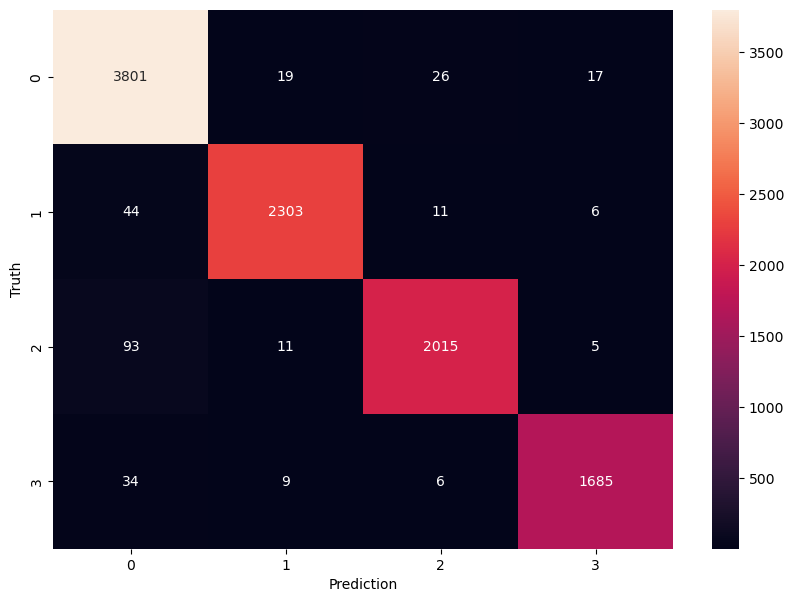

In [47]:
from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')